# Video Game Sales Analysis
## Notebook 2: Data Understanding and Exploratory Data Analysis

### Purpose

The purpose of this notebook is to explore and understand the historical
video game sales dataset before performing deeper analysis.

This notebook focuses on:

- Understanding the structure of the dataset
- Evaluating data quality
- Identifying missing or inconsistent values
- Exploring sales distributions
- Examining patterns across genres, platforms, publishers, and regions
- Identifying trends that may provide actionable business insights

The findings from this exploratory analysis will guide the later stages
of the project.


## Import Libraries for initial exploration.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load the Dataset

The dataset is loaded into a pandas DataFrame for initial inspection and exploratory analysis.

In [4]:
df = pd.read_csv("vgsales.csv")

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 3. Initial Data Inspection

Before cleaning or analyzing the dataset, the structure of the data is examined to understand its dimensions, variables, and data types.

In [5]:
df.shape


(16598, 11)

In [6]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


### Initial Inspection Findings

The dataset contains 16,598 observations and 11 variables.

Initial inspection shows that most variables are complete. However, missing values are present in the `Year` and `Publisher` columns. The `Year` variable contains 271 missing values, while `Publisher` contains 58 missing values.

The sales variables are stored as numeric values, while game names, platforms, genres, and publishers are stored as categorical/text data. The `Year` variable is currently stored as a floating-point value, which may require further investigation during data cleaning.

In [8]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [9]:
(df.isnull().sum() / len(df) * 100).round(2)

Rank            0.00
Name            0.00
Platform        0.00
Year            1.63
Genre           0.00
Publisher       0.35
NA_Sales        0.00
EU_Sales        0.00
JP_Sales        0.00
Other_Sales     0.00
Global_Sales    0.00
dtype: float64

### Missing Value Assessment

Missing values represent 1.63% of the `Year` variable and 0.35% of the
`Publisher` variable.

Because these percentages are relatively small and both variables are
important to the planned analysis, rows containing missing values in
these columns will be removed rather than imputed. Imputing a release
year or publisher could introduce inaccurate information into the
analysis.

In [10]:
df_clean = df.dropna(subset=["Year", "Publisher"]).copy()

In [11]:
df_clean.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [12]:
df_clean.shape

(16291, 11)

## 4. Duplicate Value Assessment

The cleaned dataset is examined for duplicate observations to ensure that repeated records do not distort the analysis.

In [13]:
df_clean.duplicated().sum()

np.int64(0)

In [14]:
df_clean["Year"] = df_clean["Year"].astype(int)

In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  int64  
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


## 5. Descriptive Statistics

Descriptive statistics are examined to understand the distribution, central tendency, and variability of the numerical variables in the cleaned dataset.

In [16]:
df_clean.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## 6. Global Sales Distribution

The distribution of global video game sales is examined to understand how sales are spread across titles and to identify potential skewness and extreme values.

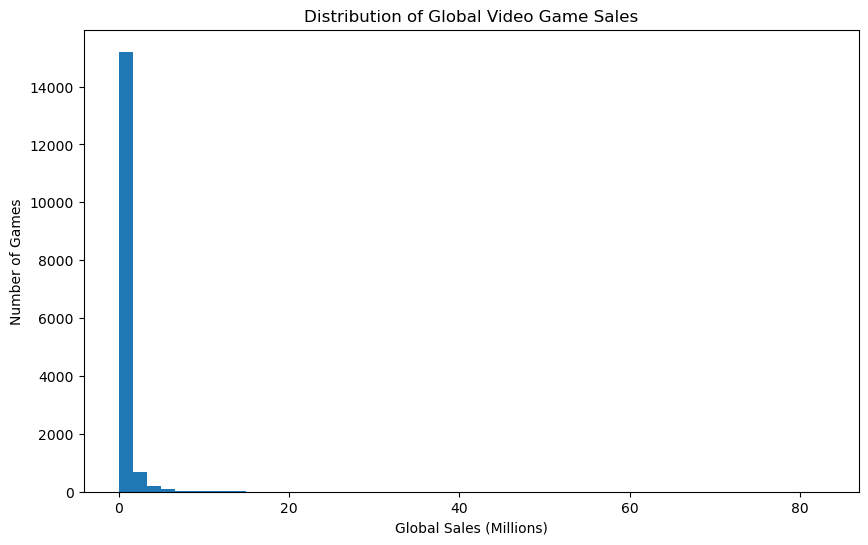

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(df_clean["Global_Sales"], bins=50)

plt.xlabel("Global Sales (Millions)")
plt.ylabel("Number of Games")
plt.title("Distribution of Global Video Game Sales")

plt.show()

### Interpretation

The distribution of global video game sales is strongly positively skewed.
Most titles have relatively low global sales, while a small number of
blockbuster games achieve exceptionally high sales.

This suggests that the mean alone may not adequately represent a typical
game's sales performance because it is influenced by a relatively small
number of extremely successful titles.

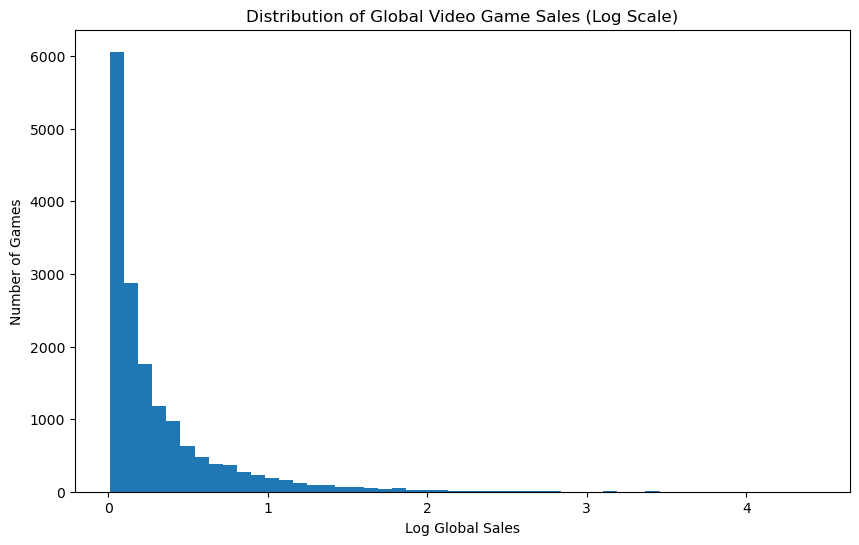

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(np.log1p(df_clean["Global_Sales"]), bins=50) # Adding 1 allows us to handle observations at near zero safely

plt.xlabel("Log Global Sales")
plt.ylabel("Number of Games")
plt.title("Distribution of Global Video Game Sales (Log Scale)")

plt.show()

## 7. Global Sales by Genre

Global sales are analyzed by genre to identify which categories have generated the greatest historical sales and to understand differences in market performance across game types.

In [19]:
genre_sales = (
    df_clean.groupby("Genre")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

genre_sales

Genre
Action          1722.84
Sports          1309.24
Shooter         1026.20
Role-Playing     923.83
Platform         829.13
Misc             789.87
Racing           726.76
Fighting         444.05
Simulation       389.98
Puzzle           242.21
Adventure        234.59
Strategy         173.27
Name: Global_Sales, dtype: float64

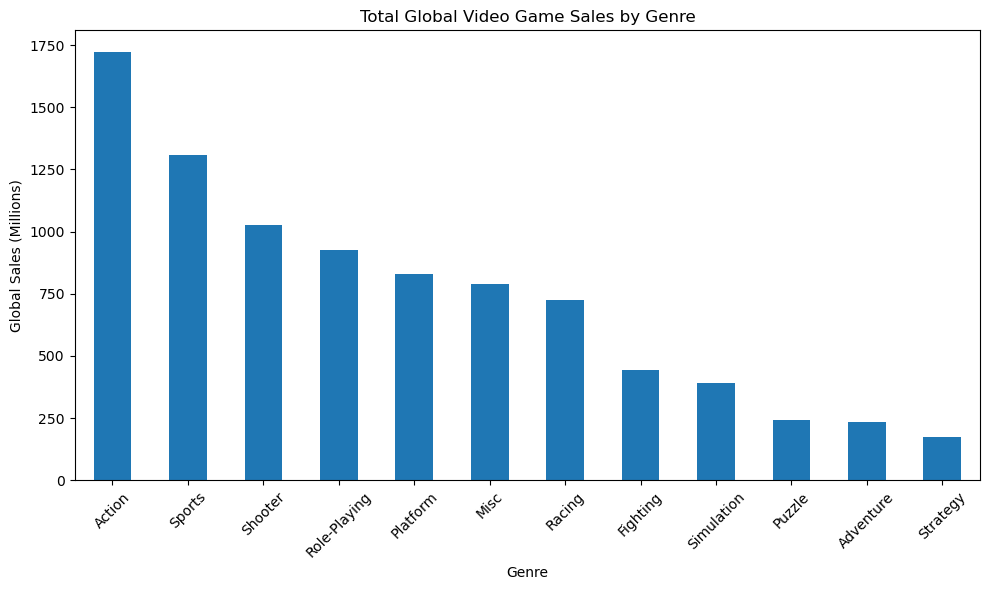

In [20]:
plt.figure(figsize=(10, 6))

genre_sales.plot(kind="bar")

plt.title("Total Global Video Game Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation

Action games generated the highest total global sales in the dataset,
followed by Sports and Shooter games. This indicates that these genres
have historically accounted for a substantial share of the video game
market.

However, total sales alone do not indicate that an individual game in
these genres typically performs better. Genres with more titles may
generate greater cumulative sales simply because more games were
released. Therefore, the number of titles and typical sales per game
should also be examined.

### Interpretation

Action games generated the highest total global sales in the dataset,
followed by Sports and Shooter games. This indicates that these genres
have historically accounted for a substantial share of the video game
market.

However, total sales alone do not indicate that an individual game in
these genres typically performs better. Genres with more titles may
generate greater cumulative sales simply because more games were
released. Therefore, the number of titles and typical sales per game
should also be examined.

In [21]:
genre_counts = (
    df_clean["Genre"]
    .value_counts()
)

genre_counts

Genre
Action          3251
Sports          2304
Misc            1686
Role-Playing    1470
Shooter         1282
Adventure       1274
Racing          1225
Platform         875
Simulation       848
Fighting         836
Strategy         670
Puzzle           570
Name: count, dtype: int64

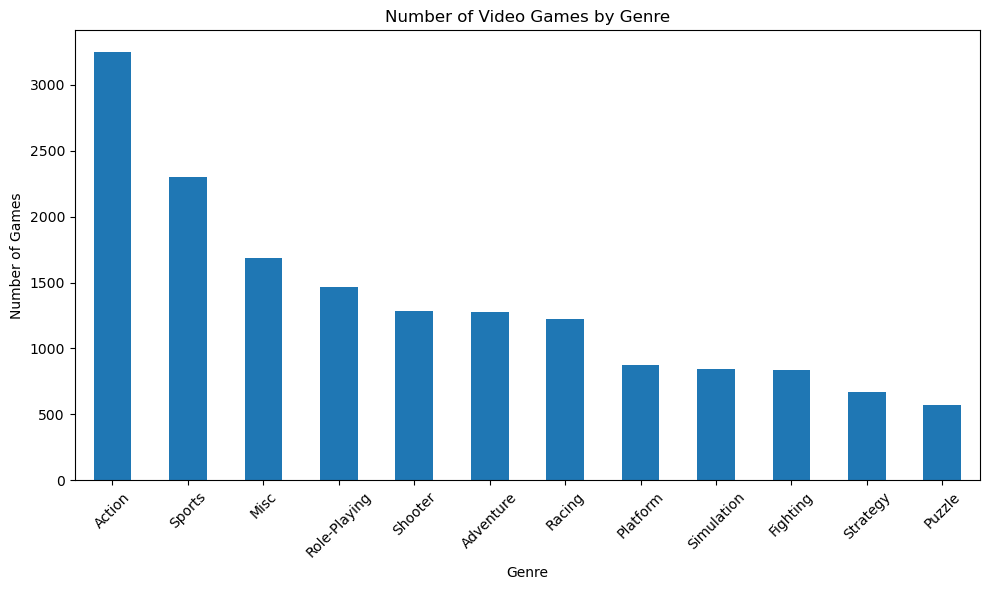

In [22]:
plt.figure(figsize=(10, 6))

genre_counts.plot(kind="bar")

plt.title("Number of Video Games by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [23]:
genre_median_sales = (
    df_clean.groupby("Genre")["Global_Sales"]
    .median()
    .sort_values(ascending=False)
)

genre_median_sales

Genre
Platform        0.280
Shooter         0.230
Sports          0.220
Fighting        0.210
Action          0.190
Racing          0.190
Role-Playing    0.190
Misc            0.160
Simulation      0.160
Puzzle          0.105
Strategy        0.090
Adventure       0.060
Name: Global_Sales, dtype: float64

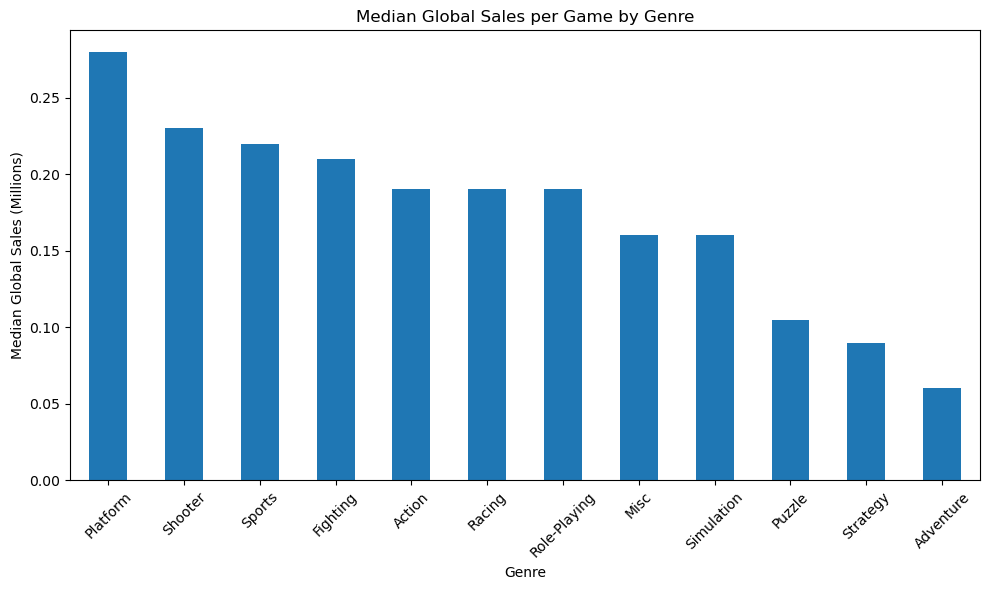

In [24]:
plt.figure(figsize=(10, 6))

genre_median_sales.plot(kind="bar")

plt.title("Median Global Sales per Game by Genre")
plt.xlabel("Genre")
plt.ylabel("Median Global Sales (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Genre Performance Insight

Although Action games generated the highest total global sales, Action
also contains substantially more titles than any other genre. When
performance is evaluated using median sales per game, Platform becomes
the strongest-performing genre, followed by Shooter and Sports.

This suggests that Action's dominance in total sales is influenced by
the large volume of Action titles released, while Platform games
historically achieved stronger typical sales performance on a
per-title basis.

## 8. Regional Sales Analysis

Regional sales are examined to determine how video game market performance differs across North America, Europe, Japan, and other regions.

In [25]:
regional_sales = df_clean[
    ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
].sum().sort_values(ascending=False)

regional_sales

NA_Sales       4327.65
EU_Sales       2406.69
JP_Sales       1284.27
Other_Sales     788.91
dtype: float64

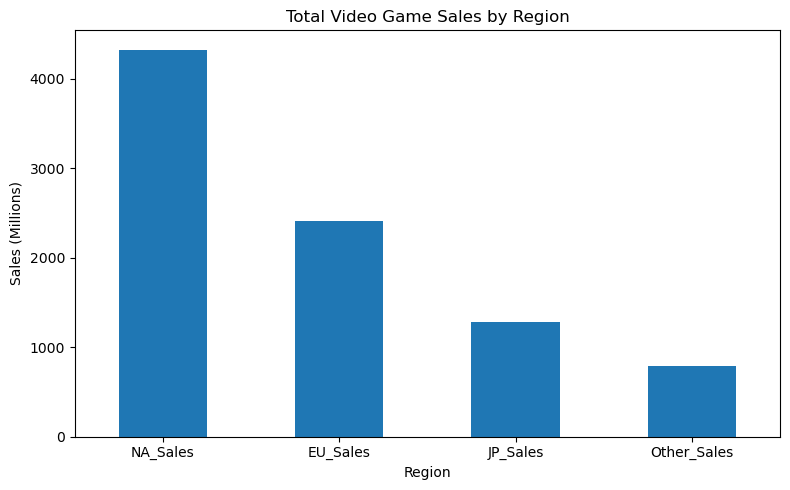

In [27]:
plt.figure(figsize=(8, 5))

regional_sales.plot(kind="bar")

plt.title("Total Video Game Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

### Regional Sales Insight

North America represents the largest source of video game sales in the
dataset, followed by Europe, Japan, and other regions.

This indicates that North America contributed the greatest share of
historical sales represented in the dataset. However, overall regional
sales do not reveal whether consumer preferences differ across regions.
Further analysis by genre is therefore needed.

In [28]:
genre_region_sales = (
    df_clean.groupby("Genre")[
        ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
    ]
    .sum()
)

genre_region_sales

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,861.77,516.48,158.65,184.92
Adventure,101.93,63.74,51.99,16.70
Fighting,220.74,100.00,87.15,36.19
Misc,396.92,211.77,106.67,73.92
Platform,445.99,200.65,130.65,51.51
Puzzle,122.01,50.52,56.68,12.47
Racing,356.93,236.31,56.61,76.68
Role-Playing,326.50,187.57,350.29,59.38
Shooter,575.16,310.45,38.18,101.90


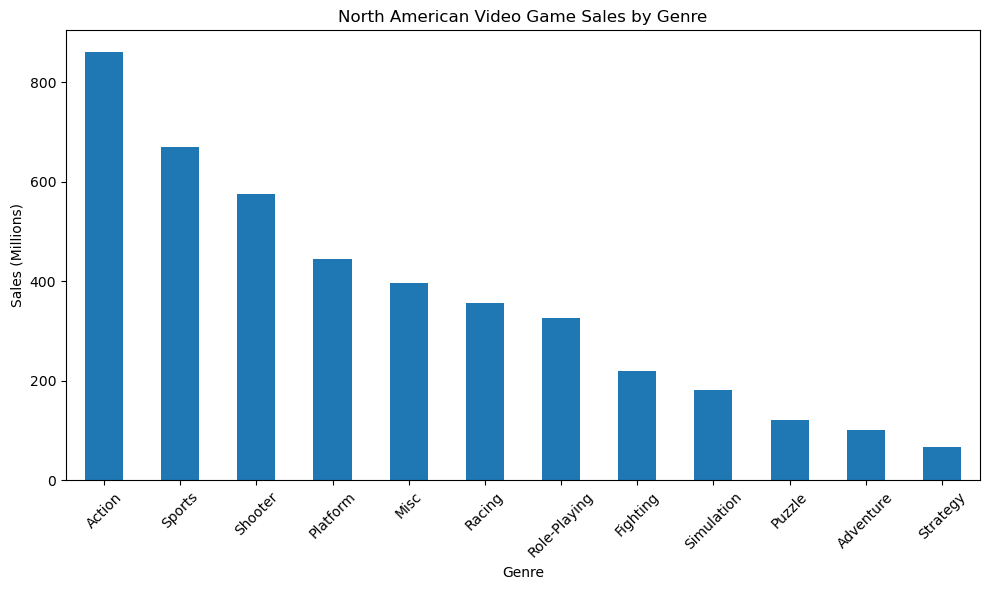

In [29]:
na_genre_sales = (
    genre_region_sales["NA_Sales"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

na_genre_sales.plot(kind="bar")

plt.title("North American Video Game Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

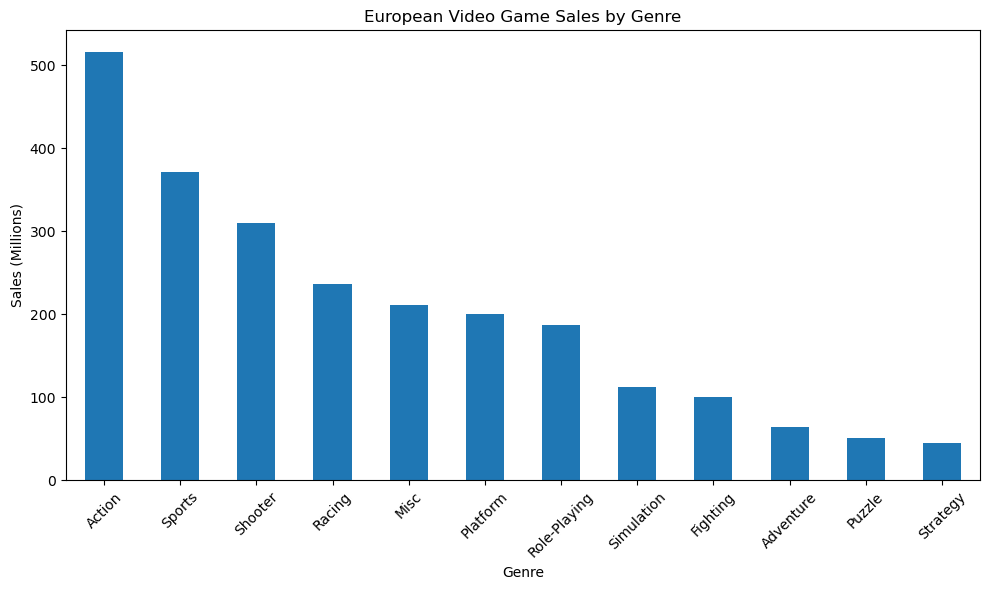

In [30]:
eu_genre_sales = (
    genre_region_sales["EU_Sales"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

eu_genre_sales.plot(kind="bar")

plt.title("European Video Game Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

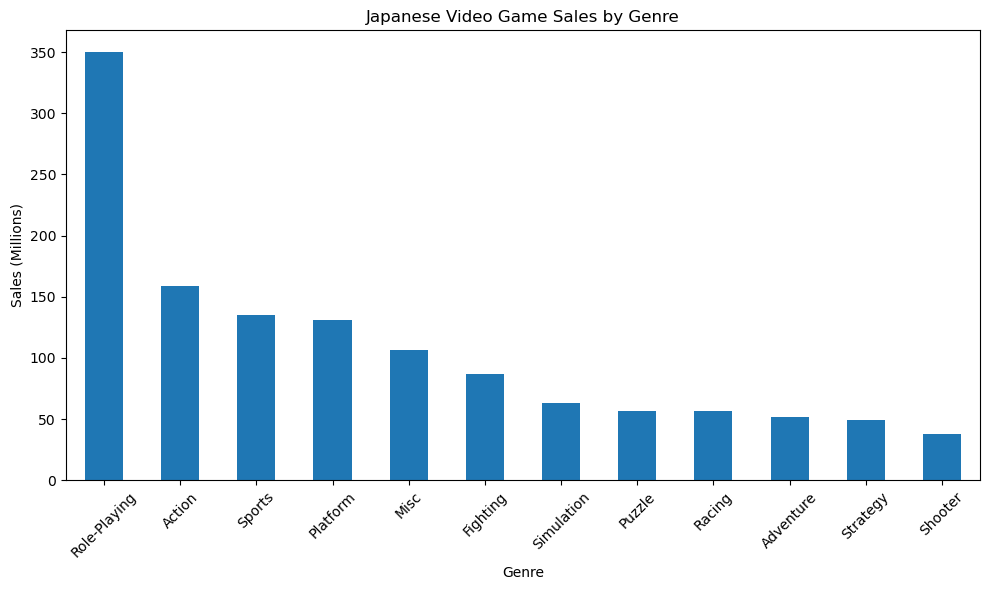

In [31]:
jp_genre_sales = (
    genre_region_sales["JP_Sales"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

jp_genre_sales.plot(kind="bar")

plt.title("Japanese Video Game Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Regional Genre Insights

Genre preferences vary considerably across geographic markets.

North America and Europe show similar patterns, with Action, Sports,
and Shooter games generating the highest historical sales. Europe also
shows relatively strong performance for Racing games.

Japan displays a substantially different market pattern. Role-Playing
games generate the highest sales by a wide margin, while Shooter games,
which perform strongly in North America and Europe, generate much lower
sales in Japan.

These differences suggest that video game companies should consider
regional consumer preferences when making product development,
localization, and marketing decisions rather than relying on a single
global genre strategy.

In [ ]:
## 9. Video Game Sales Trends Over Time

Historical global sales are examined by year to identify changes in
market activity and long-term sales patterns.

In [32]:
yearly_sales = (
    df_clean.groupby("Year")["Global_Sales"]
    .sum()
    .sort_index()
)

yearly_sales

Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    414.01
2005    458.51
2006    521.04
2007    609.92
2008    678.90
2009    667.30
2010    600.29
2011    515.80
2012    363.49
2013    368.11
2014    337.03
2015    264.44
2016     70.90
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64

In [33]:
df_clean.groupby("Year").size().tail(10)

Year
2009    1431
2010    1257
2011    1136
2012     655
2013     546
2014     580
2015     614
2016     342
2017       3
2020       1
dtype: int64

In [34]:
df_clean["Year"].value_counts().sort_index().tail(10)

Year
2009    1431
2010    1257
2011    1136
2012     655
2013     546
2014     580
2015     614
2016     342
2017       3
2020       1
Name: count, dtype: int64

### Dataset Coverage Limitation

The number of observations declines substantially in the later years of
the dataset. While 2015 contains 614 game records and 2016 contains 342,
only 3 records are available for 2017 and 1 record for 2020.

Therefore, the extremely low sales totals observed in 2017 and 2020
should not be interpreted as evidence of a collapse in the video game
market. Instead, these values indicate incomplete dataset coverage for
the later years.

For the historical trend analysis, 2017 and 2020 will be excluded to
avoid presenting incomplete years as representative of overall market
performance.

In [35]:
yearly_sales_complete = (
    df_clean[df_clean["Year"] <= 2016]
    .groupby("Year")["Global_Sales"]
    .sum()
)

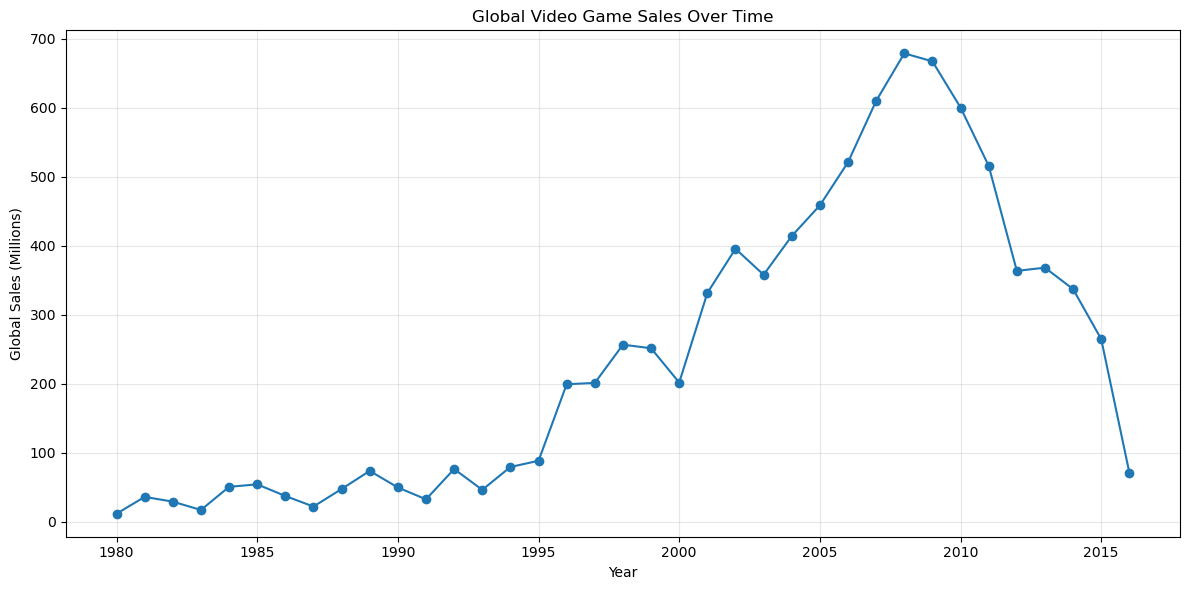

In [36]:
plt.figure(figsize=(12, 6))

yearly_sales_complete.plot(kind="line", marker="o")

plt.title("Global Video Game Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Historical Sales Trend Insight

Historical global video game sales increased substantially from the
mid-1990s through the 2000s, reaching their highest level around 2008.
Sales represented in the dataset decline after this peak.

However, the later years of the dataset contain fewer observations,
particularly 2016 and beyond. Therefore, the magnitude of the decline
near the end of the series should be interpreted cautiously because
part of the decrease may reflect incomplete dataset coverage rather
than changes in the overall video game market.

## 10. Platform Sales Analysis

Global sales are analyzed across gaming platforms to identify the
platforms that generated the highest historical sales. Because the
dataset contains many platforms, the analysis focuses initially on
the ten platforms with the highest cumulative global sales.

In [37]:
platform_sales = (
    df_clean.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_10_platforms = platform_sales.head(10)

top_10_platforms

Platform
PS2     1233.46
X360     969.60
PS3      949.35
Wii      909.81
DS       818.91
PS       727.39
GBA      305.62
PSP      291.71
PS4      278.10
PC       254.70
Name: Global_Sales, dtype: float64

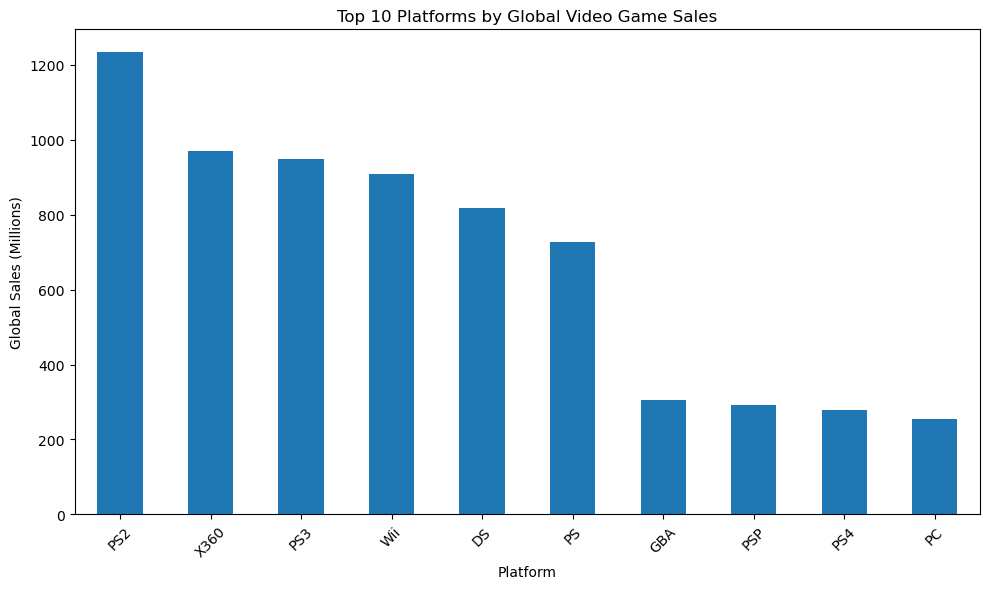

In [38]:
plt.figure(figsize=(10, 6))

top_10_platforms.plot(kind="bar")

plt.title("Top 10 Platforms by Global Video Game Sales")
plt.xlabel("Platform")
plt.ylabel("Global Sales (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [39]:
top_platform_names = top_10_platforms.index

top_platform_counts = (
    df_clean[df_clean["Platform"].isin(top_platform_names)]
    ["Platform"]
    .value_counts()
)

top_platform_counts

Platform
DS      2131
PS2     2127
PS3     1304
Wii     1290
X360    1234
PSP     1197
PS      1189
PC       938
GBA      786
PS4      336
Name: count, dtype: int64

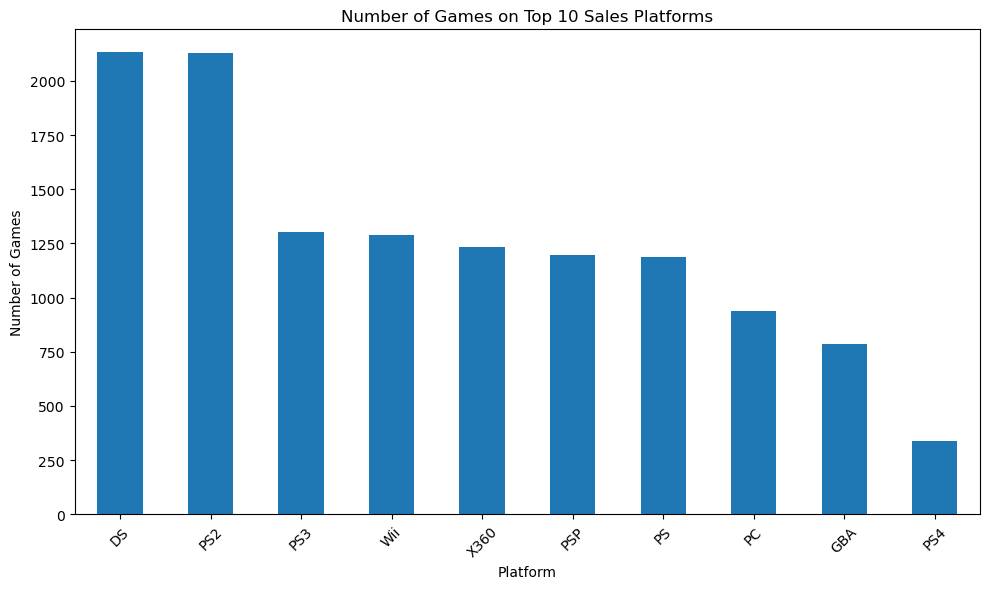

In [40]:
plt.figure(figsize=(10, 6))

top_platform_counts.plot(kind="bar")

plt.title("Number of Games on Top 10 Sales Platforms")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [41]:
platform_median_sales = (
    df_clean[df_clean["Platform"].isin(top_platform_names)]
    .groupby("Platform")["Global_Sales"]
    .median()
    .sort_values(ascending=False)
)

platform_median_sales

Platform
PS3     0.29
X360    0.29
PS      0.26
PS2     0.23
PS4     0.22
Wii     0.20
GBA     0.16
DS      0.11
PSP     0.09
PC      0.04
Name: Global_Sales, dtype: float64

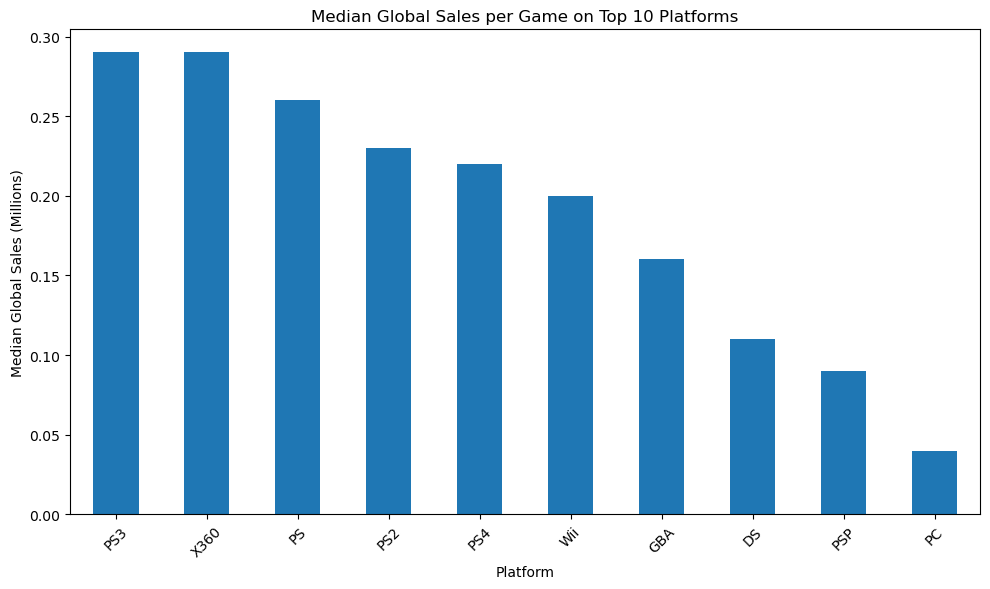

In [42]:
plt.figure(figsize=(10, 6))

platform_median_sales.plot(kind="bar")

plt.title("Median Global Sales per Game on Top 10 Platforms")
plt.xlabel("Platform")
plt.ylabel("Median Global Sales (Millions)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Platform Performance Insight

PS2 generated the highest cumulative global sales among the platforms
analyzed and also had one of the largest game libraries. However, it
did not have the highest median sales per title.

PS3 and Xbox 360 produced the highest median global sales per game among
the top-selling platforms, despite having substantially fewer titles
than PS2 and DS.

This suggests that platform performance should not be evaluated using
total sales alone. Large game libraries can contribute to high
cumulative sales, while median sales provide additional insight into
the typical performance of individual titles on each platform.

In [ ]:
## 11. Publisher Analysis

Publisher performance is examined to identify the companies associated
with the highest cumulative global video game sales in the dataset.

In [43]:
publisher_sales = (
    df_clean.groupby("Publisher")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_10_publishers = publisher_sales.head(10)

top_10_publishers

Publisher
Nintendo                        1784.43
Electronic Arts                 1093.39
Activision                       721.41
Sony Computer Entertainment      607.28
Ubisoft                          473.54
Take-Two Interactive             399.30
THQ                              340.44
Konami Digital Entertainment     278.56
Sega                             270.70
Namco Bandai Games               253.65
Name: Global_Sales, dtype: float64

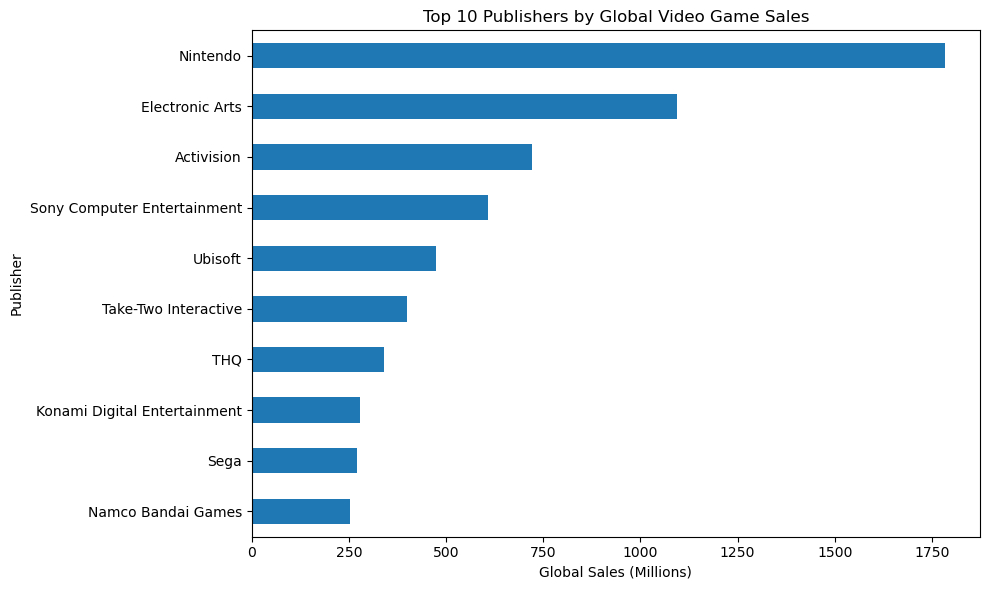

In [44]:
plt.figure(figsize=(10, 6))

top_10_publishers.sort_values().plot(kind="barh")

plt.title("Top 10 Publishers by Global Video Game Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Publisher")
plt.tight_layout()

plt.show()

### Publisher Sales Insight

Nintendo generated the highest cumulative global sales among publishers
in the dataset, followed by Electronic Arts and Activision.

However, cumulative sales alone do not determine whether Nintendo's
leadership results from publishing more titles or from stronger sales
performance per title. Additional analysis is needed to distinguish
between publishing volume and typical game performance.

In [45]:
top_publisher_names = top_10_publishers.index

publisher_counts = (
    df_clean[df_clean["Publisher"].isin(top_publisher_names)]
    ["Publisher"]
    .value_counts()
)

publisher_counts

Publisher
Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
THQ                              712
Nintendo                         696
Sony Computer Entertainment      682
Sega                             632
Take-Two Interactive             412
Name: count, dtype: int64

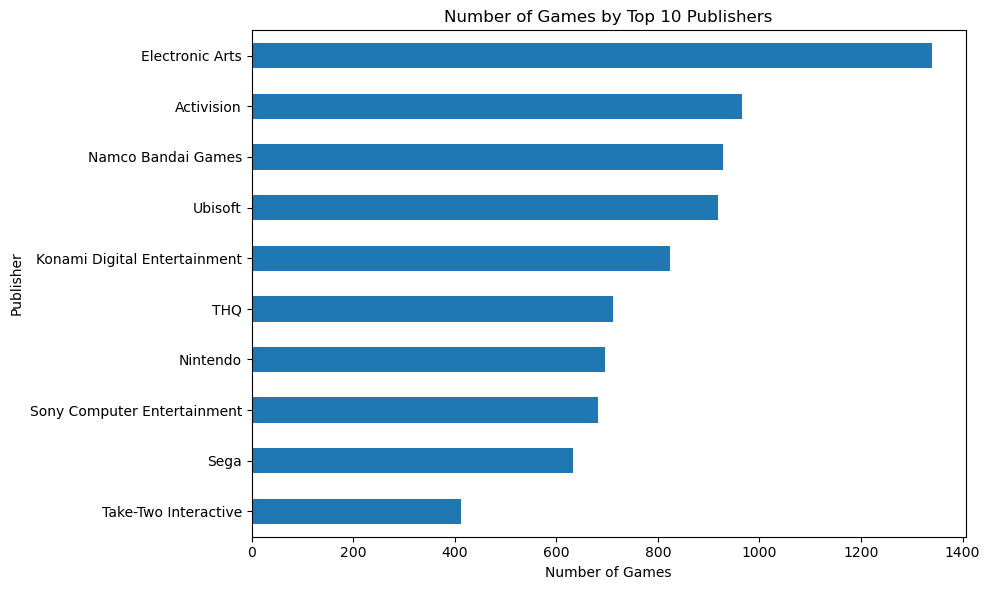

In [46]:
plt.figure(figsize=(10, 6))

publisher_counts.sort_values().plot(kind="barh")

plt.title("Number of Games by Top 10 Publishers")
plt.xlabel("Number of Games")
plt.ylabel("Publisher")
plt.tight_layout()

plt.show()

In [47]:
publisher_median_sales = (
    df_clean[df_clean["Publisher"].isin(top_publisher_names)]
    .groupby("Publisher")["Global_Sales"]
    .median()
    .sort_values(ascending=False)
)

publisher_median_sales

Publisher
Nintendo                        0.920
Electronic Arts                 0.470
Sony Computer Entertainment     0.340
Take-Two Interactive            0.305
Activision                      0.280
THQ                             0.270
Ubisoft                         0.210
Sega                            0.190
Konami Digital Entertainment    0.150
Namco Bandai Games              0.120
Name: Global_Sales, dtype: float64

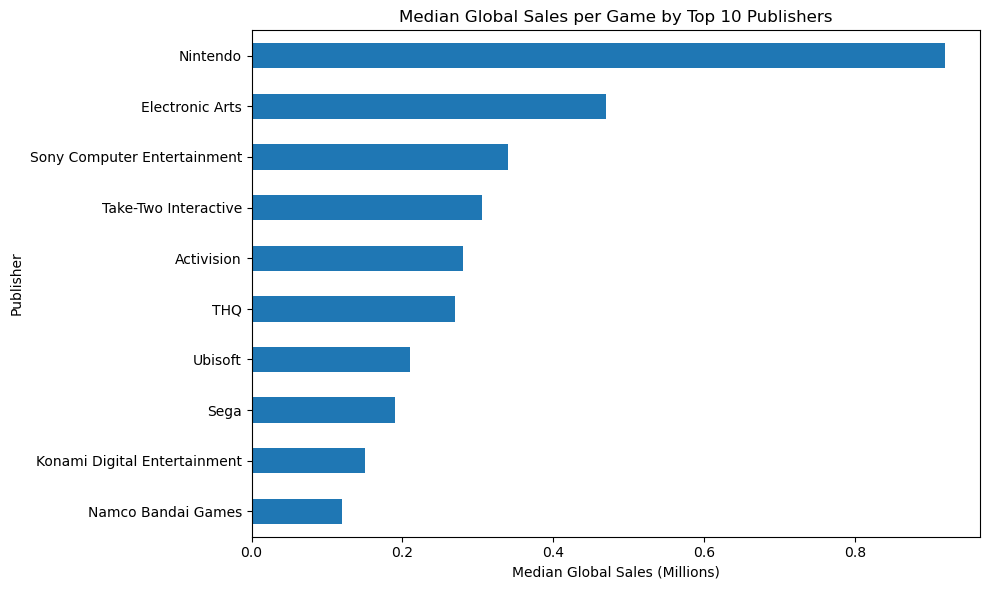

In [48]:
plt.figure(figsize=(10, 6))

publisher_median_sales.sort_values().plot(kind="barh")

plt.title("Median Global Sales per Game by Top 10 Publishers")
plt.xlabel("Median Global Sales (Millions)")
plt.ylabel("Publisher")
plt.tight_layout()

plt.show()

## 12. Exploratory Data Analysis Summary

The exploratory analysis identified several important patterns in the
historical video game sales data.

### Key Findings

1. **Sales Distribution**
   - Global video game sales are strongly positively skewed.
   - Most games generate relatively modest sales, while a small number
     of titles account for exceptionally large sales.

2. **Genre Performance**
   - Action generated the highest cumulative global sales and also had
     the largest number of titles.
   - Platform games had the highest median sales per title.
   - This indicates that high cumulative sales do not necessarily mean
     stronger typical performance per game.

3. **Regional Differences**
   - North America generated the highest overall sales.
   - North America and Europe showed similar genre preferences, with
     Action, Sports, and Shooter among the strongest categories.
   - Japan differed substantially, with Role-Playing games dominating
     historical sales.
   - These differences suggest that market strategies should account
     for regional consumer preferences.

4. **Historical Trends**
   - Sales represented in the dataset increased substantially from the
     mid-1990s through the 2000s and peaked around 2008.
   - Later years contain substantially fewer observations, so declines
     near the end of the dataset should be interpreted cautiously.

5. **Platform Performance**
   - PS2 generated the highest cumulative global sales.
   - PS3 and Xbox 360 had the highest median sales per title among the
     top-selling platforms.
   - Platform rankings therefore differ depending on whether total or
     typical per-title performance is considered.

6. **Publisher Performance**
   - Nintendo generated the highest cumulative global sales.
   - Electronic Arts published more titles, but Nintendo achieved the
     highest median sales per game among the leading publishers.
   - Nintendo's historical sales leadership therefore appears to
     reflect strong per-title performance rather than publishing volume
     alone.

### Conclusion

The exploratory analysis demonstrates that video game market
performance varies considerably across genres, platforms, publishers,
regions, and time. Total sales alone can hide important differences in
typical game performance and market structure.

These findings provide a foundation for the next stage of the project,
where the analysis can focus on translating the observed patterns into
more targeted business insights.

### Publisher Performance Insight

Nintendo generated the highest cumulative global sales despite not
having the largest number of titles among the leading publishers.

Electronic Arts published substantially more games, but Nintendo had
the highest median global sales per title by a considerable margin.

This suggests that Nintendo's historical sales leadership was driven
not only by publishing volume, but also by stronger typical sales
performance per game.

## 12. Exploratory Data Analysis Summary

The exploratory analysis identified several important patterns in the
historical video game sales data.

### Key Findings

1. **Sales Distribution**
   - Global video game sales are strongly positively skewed.
   - Most games generate relatively modest sales, while a small number
     of titles account for exceptionally large sales.

2. **Genre Performance**
   - Action generated the highest cumulative global sales and also had
     the largest number of titles.
   - Platform games had the highest median sales per title.
   - This indicates that high cumulative sales do not necessarily mean
     stronger typical performance per game.

3. **Regional Differences**
   - North America generated the highest overall sales.
   - North America and Europe showed similar genre preferences, with
     Action, Sports, and Shooter among the strongest categories.
   - Japan differed substantially, with Role-Playing games dominating
     historical sales.
   - These differences suggest that market strategies should account
     for regional consumer preferences.

4. **Historical Trends**
   - Sales represented in the dataset increased substantially from the
     mid-1990s through the 2000s and peaked around 2008.
   - Later years contain substantially fewer observations, so declines
     near the end of the dataset should be interpreted cautiously.

5. **Platform Performance**
   - PS2 generated the highest cumulative global sales.
   - PS3 and Xbox 360 had the highest median sales per title among the
     top-selling platforms.
   - Platform rankings therefore differ depending on whether total or
     typical per-title performance is considered.

6. **Publisher Performance**
   - Nintendo generated the highest cumulative global sales.
   - Electronic Arts published more titles, but Nintendo achieved the
     highest median sales per game among the leading publishers.
   - Nintendo's historical sales leadership therefore appears to
     reflect strong per-title performance rather than publishing volume
     alone.

### Conclusion

The exploratory analysis demonstrates that video game market
performance varies considerably across genres, platforms, publishers,
regions, and time. Total sales alone can hide important differences in
typical game performance and market structure.

These findings provide a foundation for the next stage of the project,
where the analysis can focus on translating the observed patterns into
more targeted business insights.

# Finally, we export the clean dataset that will be used in Notebook 3_Business Insights & Market Strategy

In [49]:
df_clean.to_csv("vgsales_clean.csv", index=False)